## Data Representation Walkthrough

In [32]:
import pandas as pd

In [33]:
df_titanic_train = pd.read_csv("titanic_train.csv")

df_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

df_titanic_clean = df_titanic_train.drop(columns=drop_cols)

df_titanic_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [35]:
df_titanic_clean.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [36]:
df_missing_rows = df_titanic_clean[df_titanic_clean.isnull().any(axis=1)]

df_missing_rows

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
5,0,3,male,NaN,0,0,8.4583,Q
17,1,2,male,NaN,0,0,13.0000,S
19,1,3,female,NaN,0,0,7.2250,C
26,0,3,male,NaN,0,0,7.2250,C
28,1,3,female,NaN,0,0,7.8792,Q
...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.2292,C
863,0,3,female,NaN,8,2,69.5500,S
868,0,3,male,NaN,0,0,9.5000,S
878,0,3,male,NaN,0,0,7.8958,S


In [37]:
# Strategy -> "mean" / "median"

class AgeImputer:
    def __init__(self, strategy, groupby_cols=None):
        self.strategy = strategy
        self.groupby_cols = groupby_cols

    def fit(self, df):
        none_missing = df.loc[df["Age"].notna()]

        if self.groupby_cols:
            self.group_stats = none_missing.groupby(self.groupby_cols)["Age"].median()
        else:
            self.group_stats = none_missing.groupby(self.groupby_cols)["Age"].mean()

        return self
    
    def transform(self, df):
        out = df.copy()

        out["Age"] = out["Age"].fillna(self.group_stats)

imputer = AgeImputer("median")
imputer.fit(df_titanic_clean)

TypeError: You have to supply one of 'by' and 'level'

In [ ]:
# Simplief version

class AgeImputer:
    def __init__(self, strategy):
        self.strategy = strategy

    def fit(self, df):
        none_missing = df.loc[df["Age"].notna()]

        if self.strategy == "median":
            self.group_stats = none_missing["Age"].median()
        else:
            self.group_stats = none_missing["Age"].mean()

        return self
    
    def transform(self, df):
        out = df.copy()

        out["Age"] = out["Age"].fillna(self.group_stats)

        return out
    
    def fit_transform(self, df):
        return self.fit(df).transform(df)

imp_median = AgeImputer("median")
df_age_median = imp_median.fit_transform(df_titanic_clean)

df_age_median.head()

imp_mean = AgeImputer("mean")
df_age_mean = imp_mean.fit_transform(df_titanic_clean)

df_age_mean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
df_age_mean.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [ ]:
categorical_cols = df_age_mean.select_dtypes(include = ["object", "category", "string", "bool"]).columns.tolist()
df_numeric = pd.get_dummies(df_age_mean, columns=categorical_cols, drop_first=False, dtype=int)

# Fill any null values just to be safe
for column in df_numeric.columns:
    if df_numeric[column].isna().any():
        df_numeric[column] = df_numeric[column].filnna(df_numeric[column].mean())

df_numeric.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

class BaseScaler:
    def fit(self, x):
        raise NotImplementedError
    
    def transform(self, x):
        raise NotImplementedError
    
    def fit_transform(self, x):
        return self.fit(x).transform(x)
    
# MinMix Scaler
class MinMaxScalerWrapper(BaseScaler):
    def __init__(self, feature_range=(0, 1)):
        self.scaler = MinMaxScaler(feature_range=feature_range)

    def fit(self, x):
        self.columns = x.columns.tolist()
        self.scaler.fit(x.values)

        return self

    def transform(self, x):
        x_transformed = self.scaler.transform(x[self.columns].values)

        return pd.DataFrame(x_transformed, columns = self.columns, index = x.index)

# ZScoreScaler

class ZScoreScalerWrapper(BaseScaler):
    def __init__(self):
        self.scaler = StandardScaler()
        self.columns = None

    def fit(self, x):
        self.columns = x.columns.tolist()
        self.scaler.fit(x.values)

        return self
    
    def transform(self, x):
        x_transformed = self.scaler.transform(x[self.columns].values)

        return pd.DataFrame(x_transformed, columns=self.columns, index=x.index)
    
minmax_scaler = MinMaxScalerWrapper()
df_minmax_scalred = minmax_scaler.fit_transform(df_numeric)

zscore_scaler = ZScoreScalerWrapper()
df_zscore_scalred = zscore_scaler.fit_transform(df_numeric)

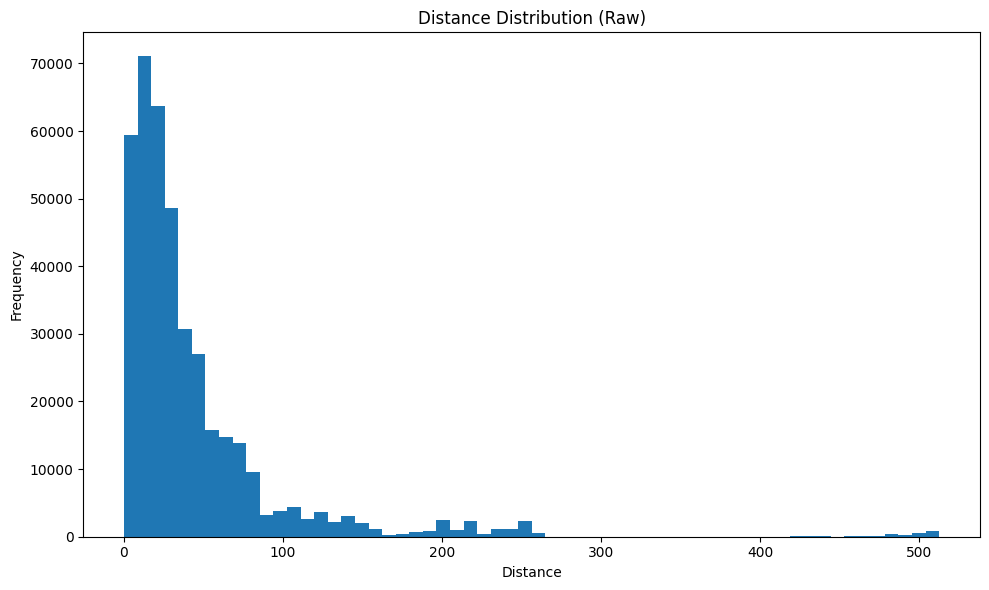

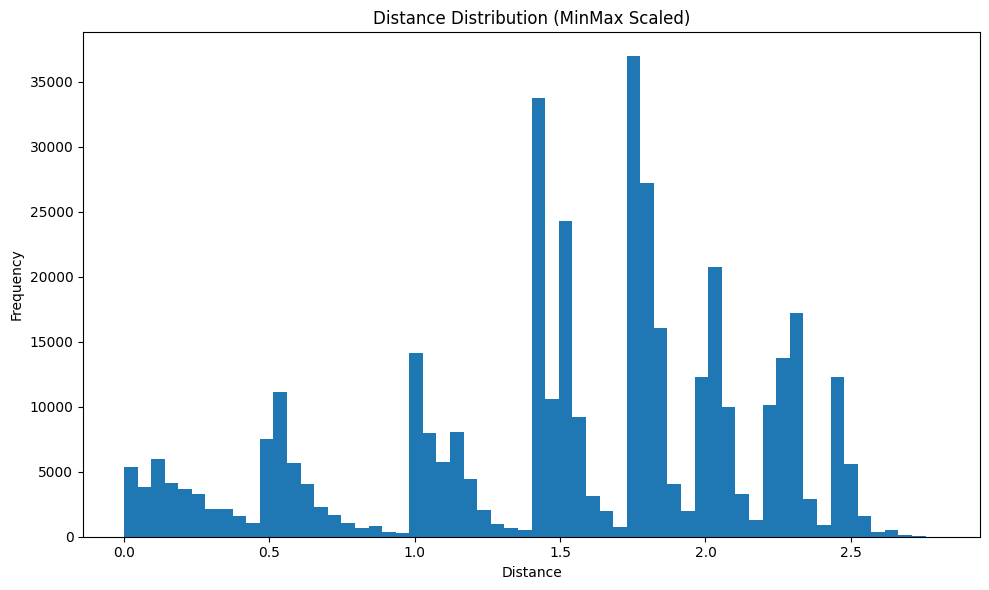

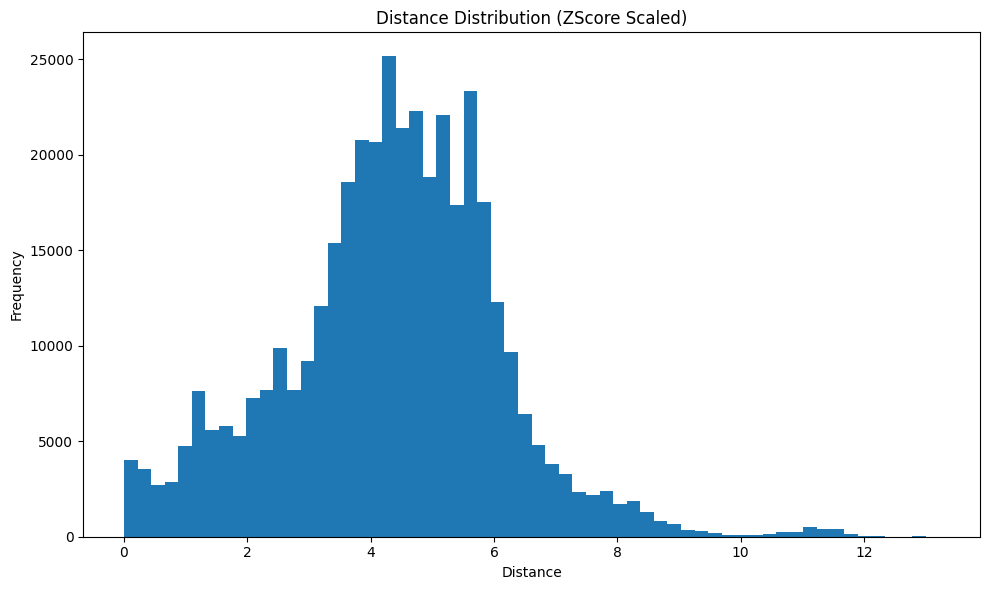

In [ ]:
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import numpy as np

def pairwise_dist_vals(x):
    D = pairwise_distances(x, metric = "euclidean")
    lower_half = np.triu_indices_from(D, k=1)

    return D[lower_half]

def plot_distance_hist(values, title, bins = 60):
    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=bins)
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

dist_raw = pairwise_dist_vals(df_numeric.values)
plot_distance_hist(dist_raw, title = "Distance Distribution (Raw)")

dist_minmax = pairwise_dist_vals(df_minmax_scalred.values)
plot_distance_hist(dist_minmax, title = "Distance Distribution (MinMax Scaled)")

dist_zscore = pairwise_dist_vals(df_zscore_scalred.values)
plot_distance_hist(dist_zscore, title = "Distance Distribution (ZScore Scaled)")